In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [153]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [154]:
df.shape

(7043, 21)

In [155]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [156]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [157]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

In [158]:
df.loc[df["TotalCharges"].str.strip() == "", ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [159]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [160]:
df["TotalCharges"].dtype

dtype('float64')

In [161]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [162]:
df.drop(columns=["customerID"], inplace=True)


In [163]:
X=df.drop(columns=["Churn"])
y=df["Churn"]


In [164]:
y=y.map({"Yes": 1, "No": 0})

In [165]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [167]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [168]:
print("Training churn distribution:")
print(y_train.value_counts(normalize=True)*100)

Training churn distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64


In [169]:
print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True)*100)


Testing churn distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [170]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [171]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()
categorical_features

C:\Users\ANEES\AppData\Local\Temp\ipykernel_29140\722448846.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [172]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False))
    ]
)

In [173]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [174]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_train_transformed.shape

(5634, 45)

In [175]:
X_test_transformed = preprocessor.transform(X_test)
X_test_transformed.shape

(1409, 45)

In [176]:
print("Original X_train shape:", X_train.shape)
print("Transformed X_train shape:", X_train_transformed.shape)

print("Original X_test shape:", X_test.shape)
print("Transformed X_test shape:", X_test_transformed.shape)

Original X_train shape: (5634, 19)
Transformed X_train shape: (5634, 45)
Original X_test shape: (1409, 19)
Transformed X_test shape: (1409, 45)


In [177]:
def evaluate_model(model_name, y_true, y_pred, y_probability):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_probability)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

In [178]:
from sklearn.linear_model import LogisticRegression

In [179]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_transformed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [180]:
y_pred_lr = logistic_model.predict(X_test_transformed)

In [181]:
y_probability_lr = logistic_model.predict_proba(
    X_test_transformed
)[:, 1]

In [182]:
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_probability_lr
)

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8055358410220014,
 'Precision': 0.6572327044025157,
 'Recall': 0.5588235294117647,
 'F1': 0.6040462427745664,
 'ROC_AUC': 0.8418610659019866}

In [183]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting = GradientBoostingClassifier(
    random_state=42
)
gradient_boosting.fit(
    X_train_transformed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [184]:
y_pred_gb = gradient_boosting.predict(
    X_test_transformed
)

y_probability_gb = gradient_boosting.predict_proba(
    X_test_transformed
)[:, 1]


In [185]:
gradient_boosting_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    y_pred_gb,
    y_probability_gb
)

gradient_boosting_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.8062455642299503,
 'Precision': 0.6735395189003437,
 'Recall': 0.5240641711229946,
 'F1': 0.5894736842105263,
 'ROC_AUC': 0.8433620088351547}

In [186]:
from sklearn.naive_bayes import GaussianNB
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(
    X_train_transformed,
    y_train
)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[4139.,1495.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.73,0.27]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,45
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 45)","[[-0.09, 0.21,-0.12,..., 0.25, 0.25, 0.25], [ 0.24,-0.58, 0.33,..., 0.12, 0.58, 0.17]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 45)","[[0.83,0.97,1.07,...,0.19,0.19,0.19], [1.38,0.65,0.67,...,0.11,0.24,0.14]]"


In [187]:
y_pred_nb=naive_bayes_model.predict(
    X_test_transformed

)
y_probability_nb = naive_bayes_model.predict_proba(
    X_test_transformed
)[:, 1]

In [188]:
naive_bayes_results = evaluate_model(
    "Naive Bayes",
    y_test,
    y_pred_nb,
    y_probability_nb

)
naive_bayes_results

{'Model': 'Naive Bayes',
 'Accuracy': 0.694819020581973,
 'Precision': 0.45894428152492667,
 'Recall': 0.8368983957219251,
 'F1': 0.5928030303030303,
 'ROC_AUC': 0.807419463173939}

In [189]:
results = pd.DataFrame([
    logistic_results,
    gradient_boosting_results,
    naive_bayes_results
])

In [190]:
results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Gradient Boosting,0.806246,0.673540,0.524064,0.589474,0.843362
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
2,Naive Bayes,0.694819,0.458944,0.836898,0.592803,0.807419


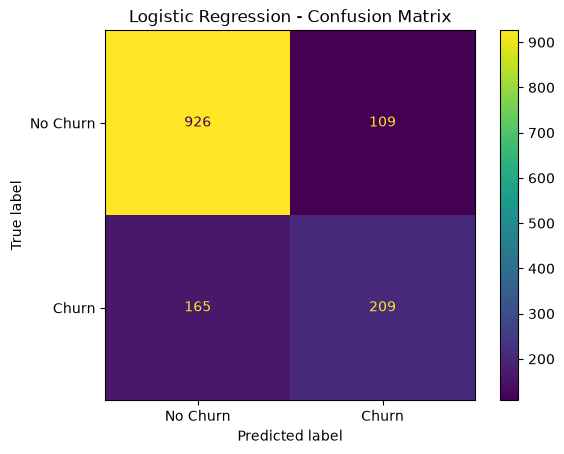

In [191]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_lr = logistic_model.predict(X_test_transformed)

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

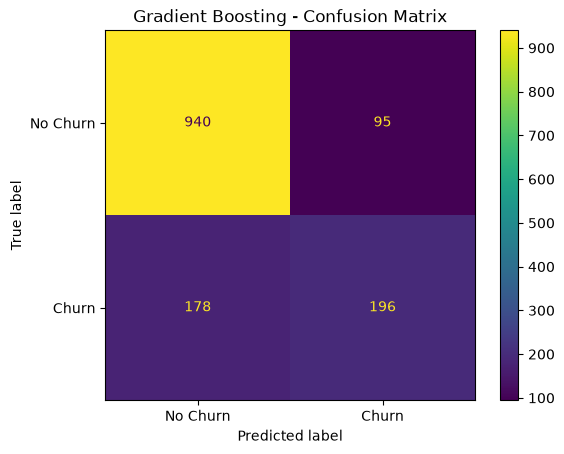

In [192]:
y_pred_gb = gradient_boosting.predict(
    X_test_transformed
)

cm = confusion_matrix(y_test, y_pred_gb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

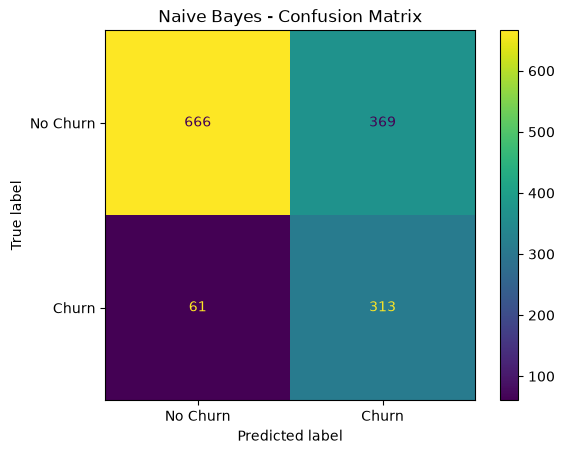

In [193]:
y_pred_nb = naive_bayes_model.predict(
    X_test_transformed
)

cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [194]:
y_probability_lr[:10]

array([0.04529387, 0.68441126, 0.05872074, 0.40170424, 0.02154772,
       0.60393536, 0.44922498, 0.13005522, 0.00288077, 0.39517899])

In [195]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [196]:
threshold = 0.40

y_pred_40 = (
    y_probability_lr >= threshold
).astype(int)

In [197]:
print(
    classification_report(
        y_test,
        y_pred_40
    )
)

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [198]:
thresholds = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

In [199]:
threshold_results = []

for threshold in thresholds:

    y_pred = (
        y_probability_lr >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred)
    })

In [200]:
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1,Accuracy
0,0.2,0.467153,0.855615,0.604344,0.702626
1,0.3,0.519337,0.754011,0.615049,0.749468
2,0.4,0.569476,0.668449,0.615006,0.777857
3,0.5,0.657233,0.558824,0.604046,0.805536
4,0.6,0.717703,0.401070,0.514580,0.799148
5,0.7,0.739130,0.181818,0.291845,0.765791
6,0.8,0.769231,0.026738,0.051680,0.739532


In [201]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.300000
Precision    0.519337
Recall       0.754011
F1           0.615049
Accuracy     0.749468
Name: 1, dtype: float64

In [202]:
best_threshold = best_threshold_row["Threshold"]

print(
    f"Best threshold based on F1: {best_threshold}"
)

Best threshold based on F1: 0.3


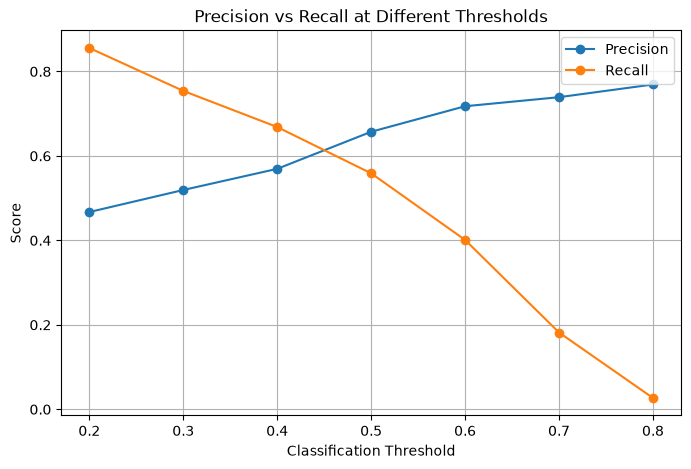

In [203]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Thresholds")
plt.legend()
plt.grid()

plt.show()

In [204]:
gb_threshold_results = []

for threshold in thresholds:

    y_pred = (
        y_probability_gb >= threshold
    ).astype(int)

    gb_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred)
    })

In [205]:
gb_threshold_df = pd.DataFrame(
    gb_threshold_results
)

gb_threshold_df

,Threshold,Precision,Recall,F1,Accuracy
0,0.2,0.486025,0.836898,0.614931,0.721789
1,0.3,0.532197,0.751337,0.623060,0.758694
2,0.4,0.589681,0.641711,0.614597,0.786373
3,0.5,0.673540,0.524064,0.589474,0.806246
4,0.6,0.742105,0.377005,0.500000,0.799858
5,0.7,0.815126,0.259358,0.393509,0.787793
6,0.8,0.803279,0.131016,0.225287,0.760823


In [206]:
gb_best_threshold_row = gb_threshold_df.loc[
    gb_threshold_df["F1"].idxmax()
]

gb_best_threshold_row

Threshold    0.300000
Precision    0.532197
Recall       0.751337
F1           0.623060
Accuracy     0.758694
Name: 1, dtype: float64

In [207]:
from sklearn.model_selection import GridSearchCV

In [208]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [209]:
lr_param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "model__solver": [
        "liblinear",
        "lbfgs"
    ]
}

In [210]:
lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [211]:
lr_grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`t

In [212]:
print(
    "Best parameters:"
)

print(
    lr_grid_search.best_params_
)

Best parameters:
{'model__C': 100, 'model__solver': 'liblinear'}


In [213]:
print(
    "Best CV ROC-AUC:",
    lr_grid_search.best_score_
)

Best CV ROC-AUC: 0.8459002792802048


In [214]:
best_lr_model = lr_grid_search.best_estimator_

In [215]:
lr_test_probability = best_lr_model.predict_proba(
    X_test
)[:, 1]

In [216]:
lr_test_prediction = (
    lr_test_probability >= 0.5
).astype(int)

In [217]:
tuned_lr_results = evaluate_model(
    "Tuned Logistic Regression",
    y_test,
    lr_test_prediction,
    lr_test_probability
)

tuned_lr_results

{'Model': 'Tuned Logistic Regression',
 'Accuracy': 0.8005677785663591,
 'Precision': 0.6466876971608833,
 'Recall': 0.5481283422459893,
 'F1': 0.5933429811866859,
 'ROC_AUC': 0.8406752951509985}

In [218]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

In [219]:
gb_param_grid = {
    "model__n_estimators": [
        100,
        200,
        300
    ],
    "model__learning_rate": [
        0.01,
        0.05,
        0.1
    ],
    "model__max_depth": [
        2,
        3,
        4
    ],
    "model__subsample": [
        0.8,
        1.0
    ]
}

In [220]:
gb_grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [221]:
gb_grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.

In [222]:
print(
    "Best parameters:"
)

print(
    gb_grid_search.best_params_
)

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}


In [223]:
print(
    "Best parameters:"
)

print(
    gb_grid_search.best_params_
)

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}


In [224]:
print(
    "Best CV ROC-AUC:",
    gb_grid_search.best_score_
)

Best CV ROC-AUC: 0.8493691666964114


In [225]:
best_gb_model = gb_grid_search.best_estimator_

In [226]:
gb_test_probability = best_gb_model.predict_proba(
    X_test
)[:, 1]

In [227]:
gb_test_prediction = (
    gb_test_probability >= 0.5
).astype(int)

In [228]:
tuned_gb_results = evaluate_model(
    "Tuned Gradient Boosting",
    y_test,
    gb_test_prediction,
    gb_test_probability
)

tuned_gb_results

{'Model': 'Tuned Gradient Boosting',
 'Accuracy': 0.8069552874378992,
 'Precision': 0.6783216783216783,
 'Recall': 0.5187165775401069,
 'F1': 0.5878787878787879,
 'ROC_AUC': 0.8477227518148235}

In [229]:
tuned_results = pd.DataFrame([
    logistic_results,
    gradient_boosting_results,
    tuned_lr_results,
    tuned_gb_results
])

In [230]:
tuned_results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Tuned Gradient Boosting,0.806955,0.678322,0.518717,0.587879,0.847723
1,Gradient Boosting,0.806246,0.673540,0.524064,0.589474,0.843362
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
2,Tuned Logistic Regression,0.800568,0.646688,0.548128,0.593343,0.840675


In [231]:
def evaluate_thresholds(
    y_true,
    probabilities,
    thresholds
):
    results = []

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        results.append({
            "Threshold": threshold,
            "Accuracy": accuracy_score(
                y_true,
                predictions
            ),
            "Precision": precision_score(
                y_true,
                predictions
            ),
            "Recall": recall_score(
                y_true,
                predictions
            ),
            "F1": f1_score(
                y_true,
                predictions
            )
        })

    return pd.DataFrame(results)

In [232]:
lr_threshold_df = evaluate_thresholds(
    y_test,
    y_probability_lr,
    np.arange(0.20, 0.81, 0.05)
)

In [233]:
lr_threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.702626,0.467153,0.855615,0.604344
1,0.25,0.733144,0.498355,0.810160,0.617108
2,0.30,0.749468,0.519337,0.754011,0.615049
3,0.35,0.765082,0.544330,0.705882,0.614668
4,0.40,0.777857,0.569476,0.668449,0.615006
5,0.45,0.789212,0.600522,0.614973,0.607662
6,0.50,0.805536,0.657233,0.558824,0.604046
7,0.55,0.799148,0.678431,0.462567,0.550079
8,0.60,0.799148,0.717703,0.401070,0.514580
9,0.65,0.788502,0.746753,0.307487,0.435606


In [234]:
lr_best_f1 = lr_threshold_df.loc[
    lr_threshold_df["F1"].idxmax()
]

lr_best_f1

Threshold    0.250000
Accuracy     0.733144
Precision    0.498355
Recall       0.810160
F1           0.617108
Name: 1, dtype: float64

In [235]:
gb_threshold_df = evaluate_thresholds(
    y_test,
    gb_test_probability,
    np.arange(0.20, 0.81, 0.05)
)

In [236]:
gb_threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.721079,0.485362,0.842246,0.615836
1,0.25,0.741661,0.508503,0.799465,0.621622
2,0.30,0.758694,0.531599,0.764706,0.627193
3,0.35,0.776437,0.562633,0.708556,0.627219
4,0.40,0.790632,0.594724,0.663102,0.627054
5,0.45,0.801987,0.633803,0.601604,0.617284
6,0.50,0.806955,0.678322,0.518717,0.587879
7,0.55,0.807665,0.713693,0.459893,0.559350
8,0.60,0.798439,0.725000,0.387701,0.505226
9,0.65,0.790632,0.780142,0.294118,0.427184


In [237]:
gb_best_f1 = gb_threshold_df.loc[
    gb_threshold_df["F1"].idxmax()
]

gb_best_f1

Threshold    0.350000
Accuracy     0.776437
Precision    0.562633
Recall       0.708556
F1           0.627219
Name: 3, dtype: float64

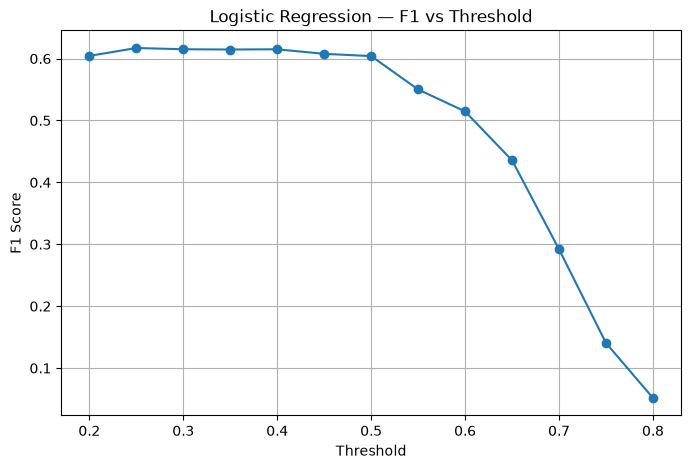

In [238]:
plt.figure(figsize=(8, 5))

plt.plot(
    lr_threshold_df["Threshold"],
    lr_threshold_df["F1"],
    marker="o"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Logistic Regression — F1 vs Threshold")
plt.grid()

plt.show()

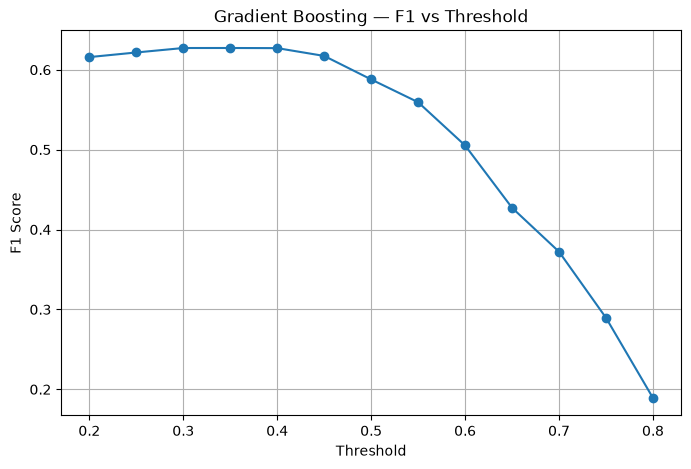

In [239]:
plt.figure(figsize=(8, 5))

plt.plot(
    gb_threshold_df["Threshold"],
    gb_threshold_df["F1"],
    marker="o"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Gradient Boosting — F1 vs Threshold")
plt.grid()

plt.show()

In [240]:
gb_best_threshold = gb_best_f1["Threshold"]

gb_final_prediction = (
    gb_test_probability >= gb_best_threshold
).astype(int)

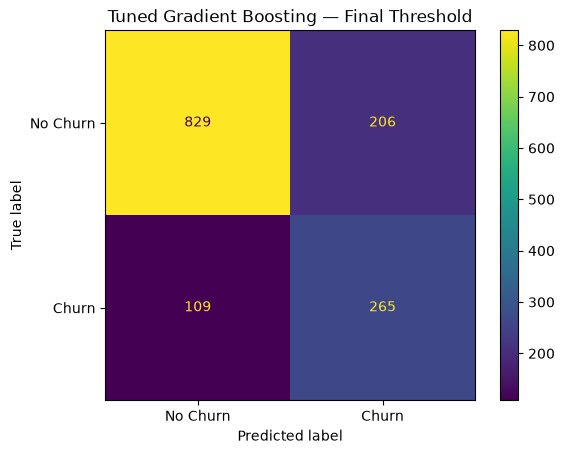

In [241]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_final_prediction,
    display_labels=["No Churn", "Churn"]
)

plt.title(
    "Tuned Gradient Boosting — Final Threshold"
)

plt.show()

In [243]:
from sklearn.metrics import roc_curve

In [244]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    y_probability_lr
)

gb_fpr, gb_tpr, _ = roc_curve(
    y_test,
    gb_test_probability
)

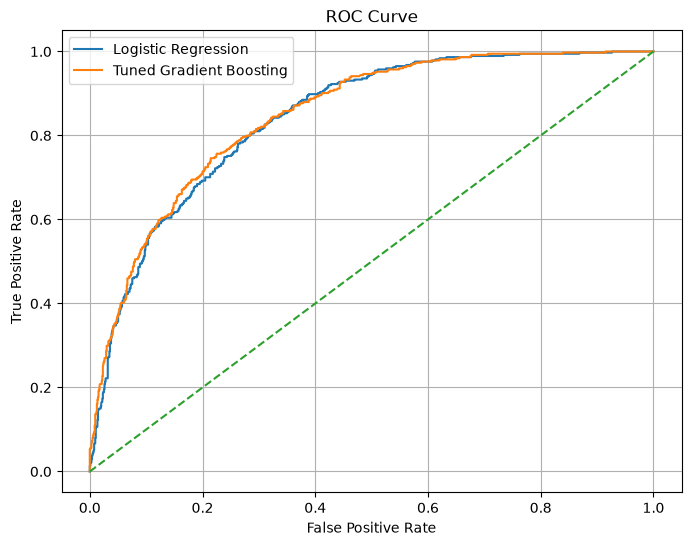

In [245]:
plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label="Tuned Gradient Boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()

In [246]:
gb_final_prediction = (
    gb_test_probability >= 0.35
).astype(int)

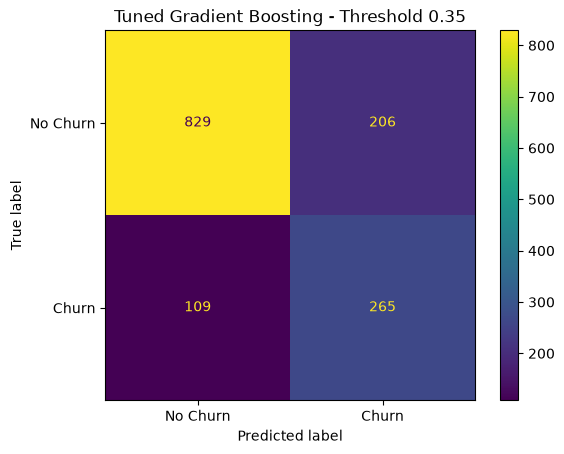

In [247]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_final_prediction,
    display_labels=["No Churn", "Churn"]
)

plt.title(
    "Tuned Gradient Boosting - Threshold 0.35"
)

plt.show()

In [248]:
print(
    classification_report(
        y_test,
        gb_final_prediction,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.56      0.71      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409



In [249]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

In [250]:
precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    gb_test_probability
)

average_precision = average_precision_score(
    y_test,
    gb_test_probability
)

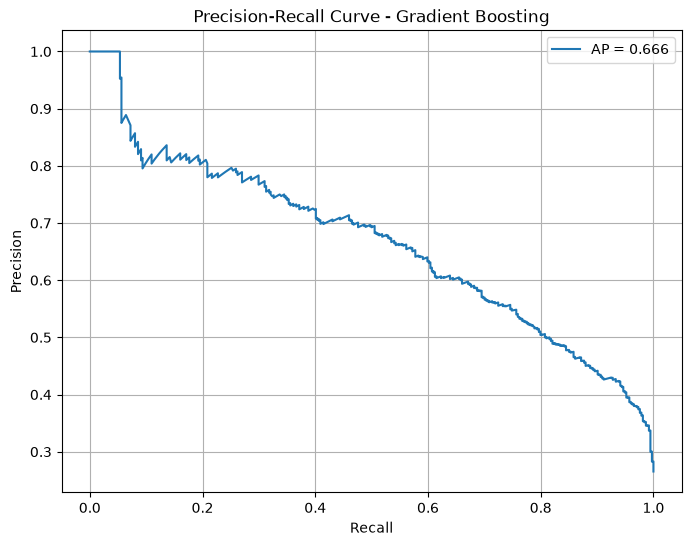

In [251]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"AP = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision-Recall Curve - Gradient Boosting"
)

plt.legend()
plt.grid()

plt.show()

In [252]:
final_threshold = 0.35

final_predictions = (
    gb_test_probability >= final_threshold
).astype(int)

In [253]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.56      0.71      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409



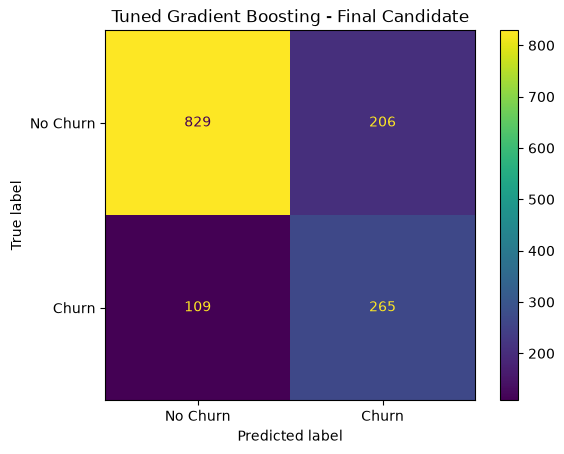

In [254]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=["No Churn", "Churn"]
)

plt.title(
    "Tuned Gradient Boosting - Final Candidate"
)

plt.show()

In [255]:
from sklearn.metrics import roc_auc_score

final_roc_auc = roc_auc_score(
    y_test,
    gb_test_probability
)

print(f"ROC-AUC: {final_roc_auc:.4f}")

ROC-AUC: 0.8477


In [256]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_results = {
    "Model": "Tuned Gradient Boosting",
    "Threshold": final_threshold,
    "Accuracy": accuracy_score(
        y_test,
        final_predictions
    ),
    "Precision": precision_score(
        y_test,
        final_predictions
    ),
    "Recall": recall_score(
        y_test,
        final_predictions
    ),
    "F1": f1_score(
        y_test,
        final_predictions
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        gb_test_probability
    )
}

final_results

{'Model': 'Tuned Gradient Boosting',
 'Threshold': 0.35,
 'Accuracy': 0.7764371894960965,
 'Precision': 0.5626326963906582,
 'Recall': 0.7085561497326203,
 'F1': 0.6272189349112426,
 'ROC_AUC': 0.8477227518148235}